In [2]:
import sys
from pathlib import Path

sys.path.insert(0,str(Path(r'C:\Users\Kinga\Desktop\MAGISTERKA\Graph-Vizualisation-Rating-Metric-3').resolve()))
# sys.path.insert(0,str(Path(r'C:\Users\ku51015\CHMURA\mystuff\Graph-Vizualisation-Rating-Metric-randoms').resolve()))

from graph_generating_script import *
from graph_metric_script import *
import matplotlib.pyplot as plt
import igraph as ig
import numpy as np
import pickle

In [49]:
# example_posdf = pd.read_csv(r'pos_dfs\0_circular_layout.csv')
# with open('graph_objects\graph_0.pkl', 'rb') as f:
#     G = pickle.load(f)

In [50]:
# zrobic df gdzie jest: graph_id+layout(czyli nazwa pliku), score, i oliczone wartosci kazdego z komponentow

# MAIN LOOP

In [3]:

# annotations = pd.read_excel('randoms_ER_annotations_scores.xlsx')
annotations = pd.read_excel('WS_annotations_scores.xlsx')

In [9]:
annotations

,graph_id,kamada_kawai,random_no1,random_no2,random_no3,random_no4,random_no5
0,0,6,2,3,4,5,1
1,1,6,2,1,3,5,4
2,2,6,1,2,3,5,4
3,3,6,1,5,4,3,2
4,4,6,1,3,5,4,2
5,5,6,4,3,1,2,5
6,6,5,2,3,1,4,6
7,7,6,3,4,5,1,2
8,8,5,3,1,2,4,6
9,9,6,1,2,4,5,3


In [12]:
import os 
posdf_dir = 'pos_dfs'
graph_dir = 'graph_objects'


calculated_components_df = pd.DataFrame(columns=['posdf_id', 'score', 
                                                 'node_distribution', 'node_distribution_raw', 
                                                 'distance_to_borderlines', 'distance_to_borderlines_raw', 
                                                 'edge_length_sum', 'edge_length_sum_raw', 
                                                 'edge_node_distance_contribution','edge_node_distance_contribution_raw', 
                                                 'count_edge_crossings',  'count_edge_crossings_raw',
                                                 'communities_closeness', 'sum_of_angles', 'symmetry'])

# Iterate through files in the posdf_dir
skip_layouts = ['lgl']

for posdf_file in os.listdir(posdf_dir):

    if posdf_file.split('_')[1].split('.')[0] not in skip_layouts:
        # reading data

        if posdf_file.endswith('.csv'):
            posdf = pd.read_csv(os.path.join(posdf_dir, posdf_file))
            print(f'Loaded {posdf_file}')

        graph_id = posdf_file.split('_')[0]
        layout = posdf_file.split('.')[0]
        if int(graph_id) < 10:
            layout = layout[2:]
        else:
            layout = layout[3:]
        score = annotations[annotations['graph_id'] == int(graph_id)][layout].values[0]


        graph_file = 'graph_' + graph_id + '.pkl' 
        with open(os.path.join(graph_dir, graph_file), 'rb') as f:
            G = pickle.load(f)
            
        components_dict = {
            'posdf_id': posdf_file,
            'score': score,
            'node_distribution': node_distribution(posdf),
            'node_distribution_raw': node_distribution_raw(posdf),
            'distance_to_borderlines': distance_to_borderlines(posdf),
            'distance_to_borderlines_raw': distance_to_borderlines_raw(posdf),
            'edge_length_sum': edge_length_sum(G, posdf),
            'edge_length_sum_raw': edge_length_sum_raw(G, posdf),
            'edge_node_distance_contribution': edge_node_distance_contribution(G, posdf)[0],
            'edge_node_distance_contribution_raw': edge_node_distance_contribution_raw(G, posdf)[0],

            'count_edge_crossings': count_edge_crossings(G, posdf),
            'count_edge_crossings_raw': count_edge_crossings_raw(G, posdf),

            'communities_closeness' : intra_cluster_distance(G, posdf)['overall_sum'],
            'sum_of_angles' : sum_of_angles(G, posdf),
            'symmetry' : measure_graph_symmetry(G, posdf)
        }
        new_row_df = pd.DataFrame([components_dict])
        calculated_components_df = pd.concat([calculated_components_df, new_row_df], ignore_index=True)

Loaded 0_kamada_kawai.csv
Loaded 0_random_no1.csv
Loaded 0_random_no2.csv
Loaded 0_random_no3.csv
Loaded 0_random_no4.csv
Loaded 0_random_no5.csv
Loaded 10_kamada_kawai.csv
Loaded 10_random_no1.csv
Loaded 10_random_no2.csv
Loaded 10_random_no3.csv
Loaded 10_random_no4.csv
Loaded 10_random_no5.csv
Loaded 11_kamada_kawai.csv
Loaded 11_random_no1.csv
Loaded 11_random_no2.csv
Loaded 11_random_no3.csv
Loaded 11_random_no4.csv
Loaded 11_random_no5.csv
Loaded 12_kamada_kawai.csv
Loaded 12_random_no1.csv
Loaded 12_random_no2.csv
Loaded 12_random_no3.csv
Loaded 12_random_no4.csv
Loaded 12_random_no5.csv
Loaded 13_kamada_kawai.csv
Loaded 13_random_no1.csv
Loaded 13_random_no2.csv
Loaded 13_random_no3.csv
Loaded 13_random_no4.csv
Loaded 13_random_no5.csv
Loaded 14_kamada_kawai.csv
Loaded 14_random_no1.csv
Loaded 14_random_no2.csv
Loaded 14_random_no3.csv
Loaded 14_random_no4.csv
Loaded 14_random_no5.csv
Loaded 15_kamada_kawai.csv
Loaded 15_random_no1.csv
Loaded 15_random_no2.csv
Loaded 15_random_

In [13]:
calculated_components_df.head(10)

,posdf_id,score,node_distribution,node_distribution_raw,distance_to_borderlines,distance_to_borderlines_raw,edge_length_sum,edge_length_sum_raw,edge_node_distance_contribution,edge_node_distance_contribution_raw,count_edge_crossings,count_edge_crossings_raw,communities_closeness,sum_of_angles,symmetry
0,0_kamada_kawai.csv,6,23.876561,17.780065,1.873066e+12,1368711.422,2.152635,3.592560,5.099386e+01,33.782377,0,0,4.595035,1.818732,0.923854
1,0_random_no1.csv,2,125.106129,33.453750,1.065740e+04,130.028,2.214927,3.371768,6.248678e+03,184.254477,4,2,4.291184,1.857574,0.994254
2,0_random_no2.csv,3,134.195630,40.020260,4.608500e+01,23.200,1.848901,3.281957,8.240742e+03,206.081081,25,5,2.975655,2.057628,0.994107
3,0_random_no3.csv,4,140.190159,39.631039,2.404800e+01,17.622,2.198073,3.399477,1.227675e+03,129.139425,16,4,3.338765,1.824807,0.983865
4,0_random_no4.csv,5,53.373121,26.006497,3.109830e+02,36.941,3.359785,4.151853,3.576057e+02,69.221441,4,2,4.698183,1.976676,0.983869
5,0_random_no5.csv,1,105.690882,37.253376,7.758000e+01,23.923,1.747610,3.093328,5.825242e+03,178.562173,9,3,3.012510,1.851889,0.988860
6,10_kamada_kawai.csv,6,26.504900,18.550923,1.001277e+04,114.313,1.891379,3.366948,5.232727e+01,33.738167,0,0,7.593441,1.864740,0.903465
7,10_random_no1.csv,4,154.683295,33.071029,7.061300e+01,24.465,2.332986,3.470395,1.672189e+03,109.140964,4,2,5.359876,2.036761,0.990024
8,10_random_no2.csv,2,95.444678,34.728589,2.014460e+02,38.047,1.404938,2.782744,2.235509e+03,118.518622,0,0,3.323339,1.519373,0.982527
9,10_random_no3.csv,3,234.534633,47.727120,5.242020e+02,47.522,1.659069,2.913046,7.881805e+07,9061.201831,1,1,1.957206,1.916982,0.979857


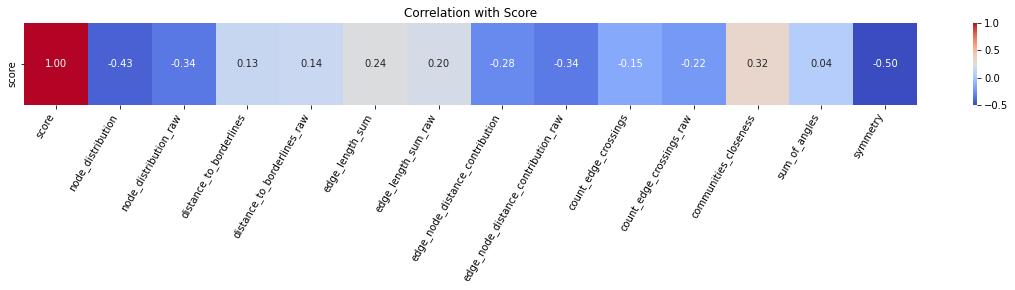

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'calculated_components_df' is already defined
calculated_components_df_numeric = calculated_components_df.drop(columns=['posdf_id'])

# Calculate the correlation matrix
correlation_matrix = calculated_components_df_numeric.corr()

# Extract the correlation of all values to 'score'
score_correlation = correlation_matrix.loc[['score']]

# Generate a heatmap for the 'score' correlation
plt.figure(figsize=(20, 1.5))  # Adjust the figure size as needed
sns.heatmap(score_correlation, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.xticks(rotation=60, ha='right')

plt.title('Correlation with Score')
plt.show()

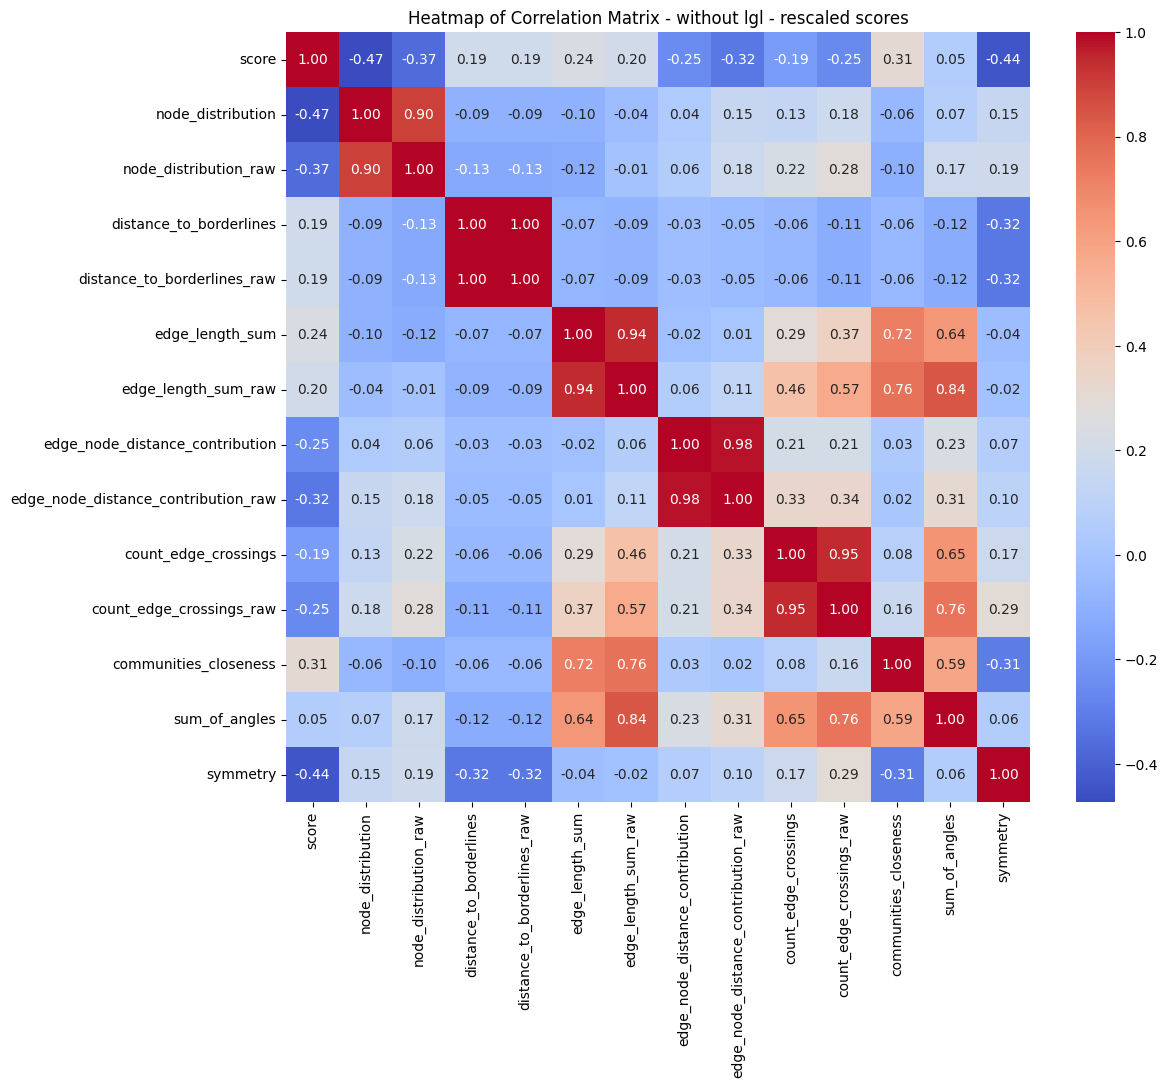

In [6]:
# Calculate the correlation matrix
# WITHOUT davidson harel
import seaborn as sns

calculated_components_df_numeric = calculated_components_df.drop(columns=['posdf_id'])
correlation_matrix = calculated_components_df_numeric.corr()

# Generate a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap of Correlation Matrix - without lgl - rescaled scores')
plt.show()